In [ ]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

import sys


from pyS3M import IOFunctions

IO = IOFunctions.IO_Functions()

from pyS3M import PlottingBase

plotter = PlottingBase.PublicationPlotter()

from pyS3M import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from pyS3M import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from pyS3M import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from pyS3M import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs(camera="zwo")

from pyS3M import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from pyS3M import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from pyS3M import SR_Functions

SupRes_F = SR_Functions.SuperRes_Functions(camera="zwo")

import pyS3M.HelperFunctions as HelperFunctions

H_F = HelperFunctions.Helper_Functions()

import pyS3M.DriftCorrectionFunctions as DCF


In [ ]:
data_folder = "../../Camera_Calibrations/ZWO_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = {"B": 0, "G": 1, "R": 2}

In [3]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [4]:
image_folder = "/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/MassiveCells/250pMATTO655_750pMCy3B_20perc561_60mW638_1"
image_files = H_F.file_search(image_folder, ".tif", "")
metadata_files = H_F.file_search(image_folder, 'metadata', '')

/home/jsb92/Documents/pyBayerSMLM/notebooks/superres_dna_paint_cells/../../src/SR_Functions.py:996: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


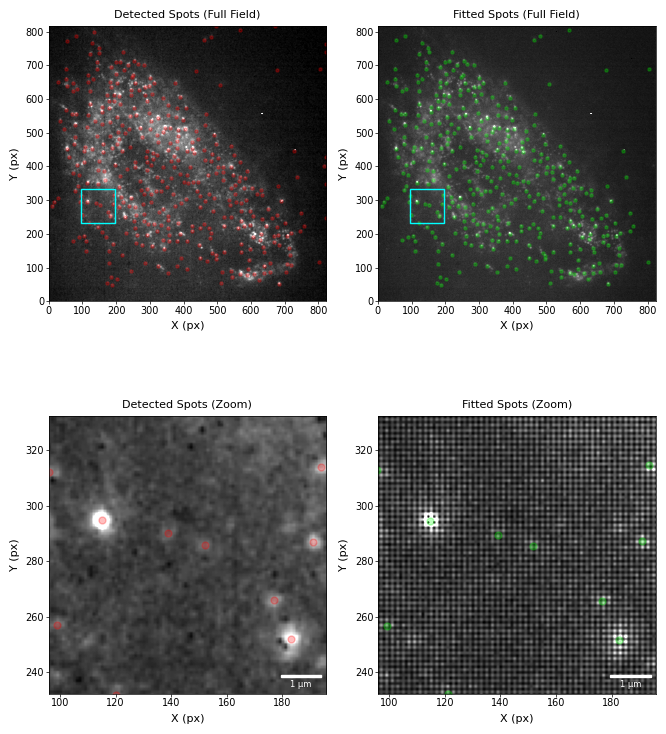

In [5]:
# play around with pfa to find a good parameter
pfa = 1e-3
sigma = 1.5
fraction_true=0.2
peak_wavelength = 0.65
frame_index = 10
fig, axs = SupRes_F.example_spots_singleframe(image_folder, pfa=pfa, sigma=sigma, fraction_true=fraction_true, 
                                              frame_index=frame_index, variance=variance, read_noise=read_noise,
                                             rqe=rqe, offset_map=offset_map, gain_map=gain_map, peak_wavelength=peak_wavelength)
plt.show()

In [ ]:
SupRes_F.fit_imaging_data(
    image_folder,
    smoothing_function,
    gain_map,
    offset_map,
    rqe,
    read_noise,
    variance=variance,
    pfa=pfa,
    ROI_size=12,
    peak_wavelength=peak_wavelength,
    fraction_true=fraction_true,
    sigma=sigma,
    NA=1.49,
    pixel_size=0.0715,
    image_type=".tif",
)